Mounted at /content/drive
Copying data on local disk
Files ready

 Loading 80000 samples ...


Loading images: 100%|██████████| 80000/80000 [01:07<00:00, 1181.93it/s]



 Start training phase...
Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 102s 232ms/step - accuracy: 0.7756 - auc: 0.8729 - loss: 0.8257 - val_accuracy: 0.5228 - val_auc: 0.6881 - val_loss: 2.2595 - learning_rate: 1.0000e-04
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 62s 196ms/step - accuracy: 0.8087 - auc: 0.9033 - loss: 0.7439 - val_accuracy: 0.7239 - val_auc: 0.8778 - val_loss: 0.9183 - learning_rate: 1.0000e-04
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 61s 196ms/step - accuracy: 0.8216 - auc: 0.9153 - loss: 0.7057 - val_accuracy: 0.7141 - val_auc: 0.8665 - val_loss: 0.7302 - learning_rate: 1.0000e-04
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 61s 195ms/step - accuracy: 0.8357 - auc: 0.9258 - loss: 0.6697 - val_accuracy: 0.7318 - val_auc: 0.8587 - val_loss: 0.7812 - learning_rate: 1.0000e-04
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 61s 195ms/step - accuracy: 0.8466 - auc: 0.9339 - loss: 0.6384 - val_accuracy: 0.8025 - val_auc: 0.8922 - val_loss: 0.6253 - learning_rate: 1.0000e-04
Epoch 6/50
313/313

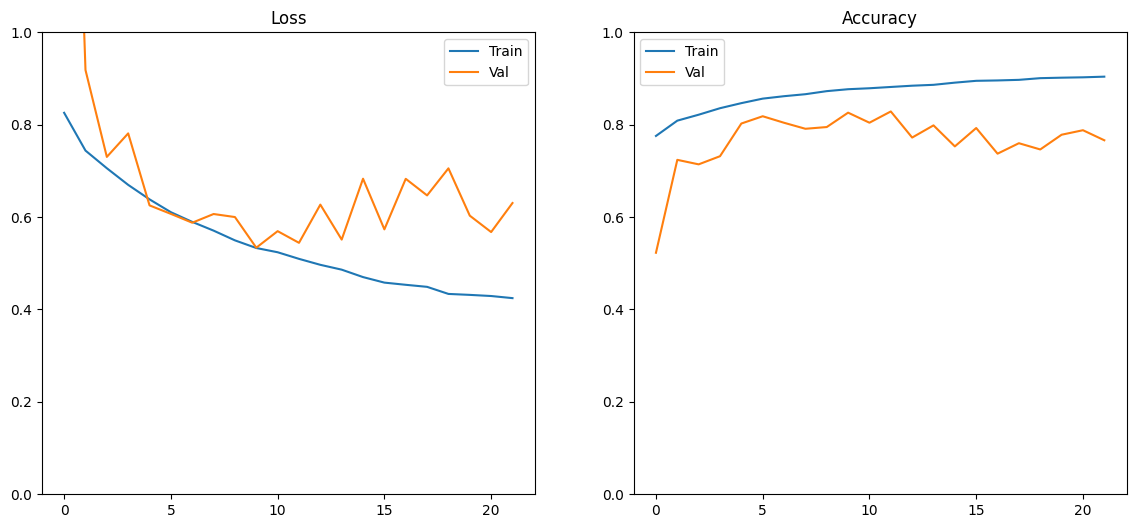


 Final evalutaion with Test set...
128/128 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step

 Final report (Threshold: 0.5)
              precision    recall  f1-score   support

     Healthy       0.71      0.86      0.78     16391
       Tumor       0.82      0.65      0.73     16377

    accuracy                           0.75     32768
   macro avg       0.77      0.75      0.75     32768
weighted avg       0.77      0.75      0.75     32768



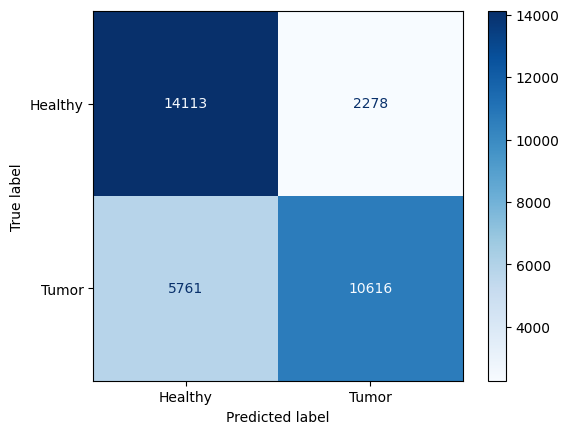

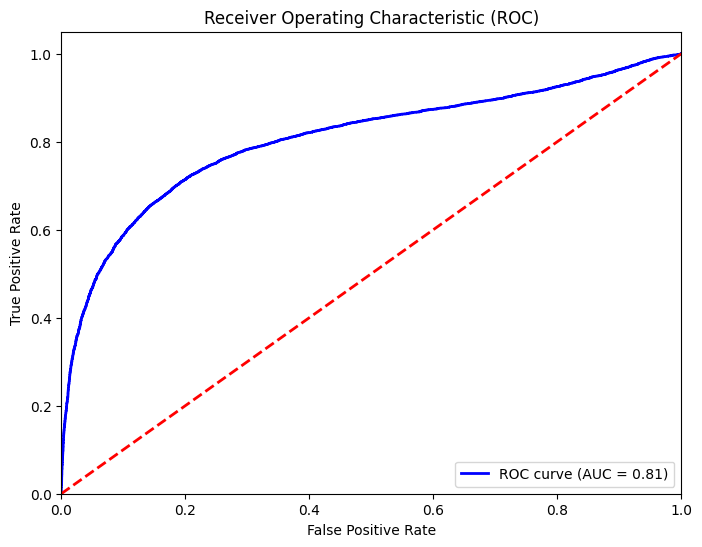

In [1]:
from google.colab import drive
import os
import h5py
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from tqdm import tqdm

if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

print("Copying data on local disk")
!rm -rf /content/*.h5
for f in ['train_x','train_y','valid_x','valid_y','test_x','test_y']:
    src = f"/content/drive/MyDrive/PCam/camelyonpatch_level_2_split_{f}.h5"
    if os.path.exists(src):
        !cp "$src" /content/
print("Files ready")

np.random.seed(42)
tf.random.set_seed(42)

# LOADING of DATA SAMPLES
def load_to_ram_safe(x_path, y_path, num_samples=80000):
    print(f"\n Loading {num_samples} samples ...")
    with h5py.File(y_path, 'r') as fy:
        y_all = fy['y'][:].reshape(-1)
        idx_0 = np.where(y_all == 0)[0]
        idx_1 = np.where(y_all == 1)[0]
        n = num_samples // 2
        selected_indices = np.concatenate([
            np.random.choice(idx_0, n, replace=False),
            np.random.choice(idx_1, n, replace=False)
        ])
        np.random.shuffle(selected_indices)

        y_final = y_all[selected_indices].reshape(-1, 1)
        del y_all

    x_final = np.empty((num_samples, 96, 96, 3), dtype='uint8')
    with h5py.File(x_path, 'r') as fx:
        ds = fx['x']
        for i, idx in enumerate(tqdm(selected_indices, desc="Loading images")):
            x_final[i] = ds[idx]

    return x_final, y_final

X_train, Y_train = load_to_ram_safe('/content/camelyonpatch_level_2_split_train_x.h5',
                                    '/content/camelyonpatch_level_2_split_train_y.h5', 80000)

with h5py.File('/content/camelyonpatch_level_2_split_valid_x.h5','r') as fx, \
     h5py.File('/content/camelyonpatch_level_2_split_valid_y.h5','r') as fy:
    X_val, Y_val = fx['x'][:8000], fy['y'][:8000].reshape(-1,1)

# RESIDUAL ARCHITECTURE
tf.keras.mixed_precision.set_global_policy('mixed_float16')

def residual_block(x, filters):
    shortcut = x
    x = layers.Conv2D(filters, 3, padding='same', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(filters, 3, padding='same', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, padding='same')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x

def build_final_resnet():
    inputs = layers.Input(shape=(96, 96, 3))
    x = layers.CenterCrop(64, 64)(inputs)
    x = layers.Rescaling(1./255)(x)
    x = layers.RandomFlip("horizontal_and_vertical")(x)
    x = layers.RandomRotation(0.15)(x)

    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = residual_block(x, 32)
    x = layers.MaxPooling2D()(x)

    x = residual_block(x, 64)
    x = layers.MaxPooling2D()(x)
    x = layers.SpatialDropout2D(0.1)(x)

    x = residual_block(x, 128)
    x = layers.MaxPooling2D()(x)

    x = residual_block(x, 256)
    x = layers.MaxPooling2D()(x)

    x = residual_block(x, 512)
    x = layers.SpatialDropout2D(0.2)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid', dtype='float32')(x)
    return models.Model(inputs, outputs)

model = build_final_resnet()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# TRAINING PHASE
class_weights = {0: 1.0, 1: 2.0}

callbacks_list = [
    callbacks.EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1)
]

print("\n Start training phase...")
history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=50,
    batch_size=256,
    class_weight=class_weights,
    callbacks=callbacks_list,
    verbose=1
)

# Saving the model
model.save('/content/drive/MyDrive/ResNet_model.keras')
print("Model saved successfully to Google Drive")

# Plot of figures
plt.figure(figsize=(14,6))
plt.subplot(1,2,1); plt.plot(history.history['loss'], label='Train'); plt.plot(history.history['val_loss'], label='Val'); plt.title("Loss"); plt.ylim(0, 1.0); plt.legend()
plt.subplot(1,2,2); plt.plot(history.history['accuracy'], label='Train'); plt.plot(history.history['val_accuracy'], label='Val'); plt.title("Accuracy"); plt.ylim(0, 1.0); plt.legend()
plt.show()

# FINAL TEST EVALUATION
print("\n Final evalutaion with Test set...")
with h5py.File('/content/camelyonpatch_level_2_split_test_x.h5','r') as fx, \
     h5py.File('/content/camelyonpatch_level_2_split_test_y.h5','r') as fy:
    X_test, Y_test = fx['x'][:], fy['y'][:].reshape(-1,1)

y_pred_prob = model.predict(X_test, batch_size=256)
threshold = 0.5
y_pred_class = (y_pred_prob > threshold).astype(int)

print(f"\n Final report (Threshold: {threshold})")
print(classification_report(Y_test, y_pred_class, target_names=["Healthy","Tumor"]))

cm = confusion_matrix(Y_test, y_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Healthy","Tumor"])
disp.plot(cmap='Blues', values_format='d')
plt.show()

# ROC Curve plotting
fpr, tpr, thresholds = roc_curve(Y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color="blue", lw=2, label="ROC curve (AUC = %0.2f)" % roc_auc)
plt.plot([0, 1], [0, 1], color="red", lw=2, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC)")
plt.legend(loc="lower right")
plt.show()